# Team Assigner — SigLIP Embedding Clustering (fixed, switch-robust)

Assigns each player track to Team 0 or Team 1 using a SigLIP visual embedding
of the **torso crop**, clustered with KMeans(k=2). Goalkeepers are assigned
separately via pitch-space centroid proximity; referees are excluded entirely.

Fixes vs. the previous version of this notebook:
- `get_torso_crop()` is now actually defined and is used by the SigLIP
  extractor (previously the full bbox was embedded — legs/shorts/socks/head
  included — even though torso-crop config existed and went unused).
- Removed dead LAB/HSV config (`COLOR_SPACE`, `USE_CHROMINANCE_ONLY`) that
  didn't match what the code actually does.
- Calibration now enumerates candidates from tracking-cache metadata first
  (no video decode, no SigLIP calls), subsamples down to
  `MAX_CALIBRATION_SAMPLES` BEFORE spending any GPU time, then does a single
  video pass that only fully decodes frames actually needed (`cap.grab()`
  elsewhere) — avoids embedding detections that would just get discarded.
- The `scaler`/`kmeans` used for classification (Cell 7) are now the same
  objects fit in Cell 5 on the real 768-dim SigLIP features — the previous
  version silently classified against a stale 4-dim LAB scaler left over
  from an earlier out-of-order run, which crashed with a feature-count
  mismatch.
- The cluster-visualization sanity-check cell now runs *after* KMeans is fit
  (previously it referenced `cluster_labels` and `get_torso_crop` before
  either existed).

**NEW — Cell 8 replaced: windowed per-track team voting instead of one
whole-track majority vote, `TEAM_VOTE_WINDOW_FRAMES=500`.** Context: the
tracking pipeline's ID-switch audit found that same-team switches (a track
silently swapping between two teammates) are a real, only partially-solved
residual failure mode. The key insight for THIS notebook specifically: a
same-team switch is invisible to team assignment by definition, since both
segments vote for the same team — only a CROSS-team switch corrupts a team
label, and the tracking notebook's KMeans-based hard team veto already
guards against most of those upstream. Rather than chase full ID-switch
elimination (the appearance model is near an information ceiling for
same-kit pairs), this notebook now votes in windows along each track's own
timeline instead of once over the whole track. 500 frames was chosen over a
smaller window (e.g. 250) as the starting point: at
`CLASSIFICATION_FRAME_STRIDE=8` a 500-frame window holds ~62 sampled votes
vs. ~31 for a 250-frame window, which matters because the match's actual
clustering separation (Cell 5's silhouette score) isn't known ahead of time
-- fewer votes per window means individual misclassified frames can more
easily tip a window's majority the wrong way, producing false
`switch_suspects` that are classifier noise rather than real switches. A
track whose team assignment is stable everywhere behaves exactly as before.
A track that flips mid-way is now DETECTED (`switch_suspects`, printed
explicitly) and its segments get the CORRECT team each, instead of one team
silently winning a global vote and mislabeling part of the track. This also
makes the downstream goalkeeper-centroid calculation in Cell 9
switch-robust, since it now attributes each sampled position to the team
that was actually in effect at that frame, not a single track-wide label.

Run cells top to bottom. Fill in paths in Cell 1. This has not been executed
in this environment (no GPU / no HF Hub access here) — run it in your Kaggle
session and check each cell's output before moving to the next, per usual.


**NEW — Cell 7 (classification) now checks for a pre-existing checkpoint first.**
The ~44min classification pass (70,326 frames @ 54.52 frame/s on a Kaggle T4)
is expensive to redo. If
`/kaggle/input/datasets/zeinsaad/barca-atletico-first-half/team_classification_checkpoint.pkl`
exists (e.g. uploaded as a Kaggle dataset from a prior run), Cell 7 loads
`raw_team_votes`/`per_frame_team` from it directly and skips the video pass
entirely. If it doesn't exist, Cell 7 runs the full classification loop as
before, then saves a checkpoint to `/kaggle/working/` (writable) so the NEXT
run can skip it too, once you upload that output as a dataset. Note
`/kaggle/input/` is read-only from within a session -- this run's own output
checkpoint will save to `/kaggle/working/`, not directly overwrite the input
path; upload it as a new dataset version between runs if you want future
sessions to pick it up from `/kaggle/input/` too.


**NEW — Cell 5b added: auto team-color extraction.** Computes the real
average BGR kit color per KMeans cluster from the actual torso-crop pixels
(not the SigLIP embedding) used during calibration -- reuses the same
frames already decoded for calibration, no extra video pass. This closes a
separate bug: hardcoding TEAM_COLORS by cluster label (0/1) in the render
code is fragile, since KMeans' cluster label assignment is arbitrary per
run -- a rerun of calibration can silently flip which numeric label is
which real team, flipping the rendered colors even though classification
itself is unaffected. team_colors ties the color to each cluster's actual
pixel content instead, so it self-corrects across reruns. Saved into the
final cache as team_colors: {0: (b,g,r), 1: (b,g,r)}.


## Cell 1 — Config

In [10]:
import os
import cv2
import pickle
import numpy as np
import torch
from pathlib import Path
from collections import defaultdict

TRACKING_CACHE_PATH = "/kaggle/input/datasets/zeinsaad/barca-atletico-first-half/barca_atletico_tracking_cache_final_fixed.pkl"   # output of tracking_pipeline
VIDEO_PATH = "/kaggle/input/datasets/zeinsaad/barca-atletico-first-half/barca_atletico_46m53s.mkv"
HOMOGRAPHY_CACHE_PATH = "/kaggle/input/datasets/zeinsaad/barca-atletico-first-half/homography_cache_barca_atletico_firsthalf.pkl"

OUTPUT_TEAM_CACHE_PATH = "barca_atletico_team_assignment.pkl"
OUTPUT_VIDEO_PATH = "barca_atletico_team_annotated.mp4"

# ---- torso crop: avoid shorts/socks/skin/head, focus on the jersey ----
# these are actually used by extract_siglip_embedding() below (previously
# defined but silently ignored)
TORSO_TOP_RATIO = 0.15      # skip the top 15% of the box (head/neck)
TORSO_BOTTOM_RATIO = 0.50   # keep only up to 50% of box height (avoid shorts)
TORSO_SIDE_MARGIN = 0.20    # crop in 20% from each side (avoid arms/background)
MIN_BBOX_AREA = 900         # px^2, filters out small/distant crops from calibration

# ---- calibration sampling ----
CALIBRATION_FRAME_STRIDE = 15     # frames sampled to FIT the KMeans clusters
CLASSIFICATION_FRAME_STRIDE = 8   # frames sampled to CLASSIFY each track (majority vote doesn't need every frame)
MAX_CALIBRATION_SAMPLES = 6000    # cap AFTER collecting across the whole match, not a hard stop mid-video

# ---- smoothing ----
SMOOTHING_WINDOW = 7   # frames, matches your earlier majority-vote smoothing window (kept for reference;
                        # actual locking here uses full-track vote totals, see Cell 8)
WEAK_MAJORITY_THRESHOLD = 0.7   # below this fraction, flag the track for manual review

# ---- pitch projection (for goalkeeper assignment) ----
PX_PER_METER = 10
PITCH_LENGTH_M = 105.0
PITCH_WIDTH_M = 68.0

# ---- SigLIP ----
SIGLIP_MODEL_NAME = "google/siglip-base-patch16-224"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
if DEVICE == "cpu":
    print("WARNING: CUDA not available, falling back to CPU. SigLIP extraction over "
          "the full match will be slow -- consider running on a Kaggle/Colab GPU session.")

print("Checking paths...")
for p in [TRACKING_CACHE_PATH, VIDEO_PATH, HOMOGRAPHY_CACHE_PATH]:
    print(p, "->", "OK" if os.path.exists(p) else "MISSING")

# ---- classification checkpoint (skip the ~44min Cell 7 pass if one already exists) ----
CLASSIFICATION_CHECKPOINT_INPUT_PATH = "/kaggle/input/datasets/zeinsaad/barca-atletico-first-half/team_classification_checkpoint_fixed.pkl"
CLASSIFICATION_CHECKPOINT_SAVE_PATH = "/kaggle/working/team_classification_checkpoint.pkl"


Checking paths...
/kaggle/input/datasets/zeinsaad/barca-atletico-first-half/barca_atletico_tracking_cache_final_fixed.pkl -> OK
/kaggle/input/datasets/zeinsaad/barca-atletico-first-half/barca_atletico_46m53s.mkv -> OK
/kaggle/input/datasets/zeinsaad/barca-atletico-first-half/homography_cache_barca_atletico_firsthalf.pkl -> OK


## Cell 2 — Load tracking cache + homography cache

In [11]:
with open(TRACKING_CACHE_PATH, "rb") as f:
    saved = pickle.load(f)

# tracking_pipeline saves {"tracking_cache":, "locked_class_by_id":}; older notebooks
# may have saved the tracking_cache directly -- handle both formats
if isinstance(saved, dict) and "tracking_cache" in saved:
    tracking_cache = saved["tracking_cache"]
    locked_class_by_id = saved["locked_class_by_id"]
else:
    tracking_cache = saved
    # fall back to raw per-frame majority class if no separate lock dict was saved
    votes = defaultdict(lambda: defaultdict(int))
    for data in tracking_cache.values():
        for t in data["tracks"]:
            votes[t["track_id"]][t["class"]] += 1
    locked_class_by_id = {tid: max(v, key=v.get) for tid, v in votes.items()}

with open(HOMOGRAPHY_CACHE_PATH, "rb") as f:
    homography_cache = pickle.load(f)

def get_homography(frame_idx):
    '''Homography cache may be a list indexed by frame or a dict keyed by frame_idx -- handle both.'''
    if isinstance(homography_cache, dict):
        return homography_cache.get(frame_idx)
    if 0 <= frame_idx < len(homography_cache):
        return homography_cache[frame_idx]
    return None

cap_tmp = cv2.VideoCapture(VIDEO_PATH)
total_frames = int(cap_tmp.get(cv2.CAP_PROP_FRAME_COUNT))
cap_tmp.release()

print(f"Tracking cache: {len(tracking_cache)} frames")
print(f"Locked classes: {len(locked_class_by_id)} tracks")
print(f"Homography cache: {len(homography_cache)} entries")
print(f"Video total frames: {total_frames}")


Tracking cache: 70326 frames
Locked classes: 114 tracks
Homography cache: 70327 entries
Video total frames: 70327


## Cell 3 — SigLIP model + torso-crop helper
`get_torso_crop` applies the ratios from Cell 1 to isolate the jersey region. `extract_siglip_embedding` now actually uses it, instead of embedding the full bbox.

In [12]:
from transformers import SiglipVisionModel, SiglipImageProcessor
from PIL import Image

siglip_processor = SiglipImageProcessor.from_pretrained(SIGLIP_MODEL_NAME)
siglip_model = SiglipVisionModel.from_pretrained(SIGLIP_MODEL_NAME).to(DEVICE).eval()


def get_torso_crop(frame, bbox):
    '''Crop the torso region of a player bbox: skip head/neck, stop before shorts,
    trim side margins to avoid arms/background bleed. Returns None if the resulting
    crop is empty or the original bbox is smaller than MIN_BBOX_AREA.'''
    x1, y1, x2, y2 = bbox
    h_img, w_img = frame.shape[:2]

    box_w, box_h = (x2 - x1), (y2 - y1)
    if box_w <= 0 or box_h <= 0 or (box_w * box_h) < MIN_BBOX_AREA:
        return None

    top = y1 + TORSO_TOP_RATIO * box_h
    bottom = y1 + TORSO_BOTTOM_RATIO * box_h
    left = x1 + TORSO_SIDE_MARGIN * box_w
    right = x2 - TORSO_SIDE_MARGIN * box_w

    x1c, y1c, x2c, y2c = int(round(left)), int(round(top)), int(round(right)), int(round(bottom))
    x1c, y1c = max(0, x1c), max(0, y1c)
    x2c, y2c = min(w_img, x2c), min(h_img, y2c)

    if x2c <= x1c or y2c <= y1c:
        return None

    return frame[y1c:y2c, x1c:x2c]


@torch.no_grad()
def extract_siglip_embedding(frame_bgr, bbox):
    torso = get_torso_crop(frame_bgr, bbox)
    if torso is None or torso.size == 0:
        return None

    crop_rgb = cv2.cvtColor(torso, cv2.COLOR_BGR2RGB)
    pil_crop = Image.fromarray(crop_rgb)

    inputs = siglip_processor(images=pil_crop, return_tensors="pt").to(DEVICE)
    outputs = siglip_model(**inputs)
    emb = outputs.pooler_output.squeeze(0).cpu().numpy()

    norm = np.linalg.norm(emb)
    return emb / norm if norm > 0 else emb


print("SigLIP embedding extractor ready (torso-crop enabled).")


Loading weights:   0%|          | 0/208 [00:00<?, ?it/s]

SiglipVisionModel LOAD REPORT from: google/siglip-base-patch16-224
Key                                                          | Status     |  | 
-------------------------------------------------------------+------------+--+-
text_model.encoder.layers.{0...11}.layer_norm1.weight        | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm1.bias          | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc1.bias              | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.v_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm2.weight        | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc1.weight            | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm2.bias          | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.k_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc2.weight            | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.v_proj.b

SigLIP embedding extractor ready (torso-crop enabled).


## Cell 4 — Sample calibration features across the whole match
Only from tracks locked as `player` — goalkeeper and referee are excluded from clustering entirely. Samples span the full video; if more than `MAX_CALIBRATION_SAMPLES` are collected, a random subsample is taken afterward so calibration isn't biased toward the start of the match.

In [13]:
player_ids = {tid for tid, cls in locked_class_by_id.items() if cls == "player"}
print(f"Player-class tracks eligible for calibration: {len(player_ids)}")

# ---- pass 1: enumerate candidates from tracking_cache metadata only, no video decode,
# no SigLIP calls yet. This is what lets the random subsample happen BEFORE spending any
# GPU time, instead of after wastefully embedding every eligible detection in the match. ----
candidates = []   # (frame_idx, track_id, bbox)
for frame_idx, data in tracking_cache.items():
    if frame_idx % CALIBRATION_FRAME_STRIDE != 0:
        continue
    for t in data["tracks"]:
        if t["track_id"] in player_ids:
            candidates.append((frame_idx, t["track_id"], t["bbox"]))

print(f"Eligible calibration candidates across the full match: {len(candidates)}")

if len(candidates) > MAX_CALIBRATION_SAMPLES:
    rng = np.random.default_rng(42)
    keep_idx = rng.choice(len(candidates), size=MAX_CALIBRATION_SAMPLES, replace=False)
    keep_idx.sort()
    candidates = [candidates[i] for i in keep_idx]
    print(f"Subsampled down to {MAX_CALIBRATION_SAMPLES} (random, spanning full match range) "
          f"BEFORE running SigLIP -- avoids embedding detections that would just be discarded.")

# index selected candidates by frame so the video pass only decodes/embeds what's needed
candidates_by_frame = defaultdict(list)
for frame_idx, track_id, bbox in candidates:
    candidates_by_frame[frame_idx].append((track_id, bbox))

last_needed_frame = max(candidates_by_frame.keys()) if candidates_by_frame else -1
print(f"Frames actually needing a decode: {len(candidates_by_frame)} "
      f"(last one at frame {last_needed_frame}/{total_frames})")

# ---- pass 2: single video decode, but only through the last needed frame. cap.grab()
# (decode only, no color conversion / buffer copy) is used for frames with no selected
# candidate; cap.read() (full retrieve) only happens on the ~3-5% of frames we actually
# need -- avoids paying full read() cost on frames that get thrown away either way. ----
calibration_features = []
calibration_meta = []   # (frame_idx, track_id) aligned with calibration_features

cap = cv2.VideoCapture(VIDEO_PATH)
frame_idx = 0
while frame_idx <= last_needed_frame:
    if frame_idx in candidates_by_frame:
        ret, frame = cap.read()
        if not ret:
            break
        for track_id, bbox in candidates_by_frame[frame_idx]:
            feat = extract_siglip_embedding(frame, bbox)
            if feat is not None:
                calibration_features.append(feat)
                calibration_meta.append((frame_idx, track_id))
    else:
        ret = cap.grab()
        if not ret:
            break

    if frame_idx % 5000 == 0:
        print(f"  scanning frame {frame_idx}/{last_needed_frame} -- {len(calibration_features)} samples so far")
    frame_idx += 1

cap.release()

calibration_features = np.array(calibration_features)
print(f"\nCollected {len(calibration_features)} SigLIP calibration embeddings "
      f"(decode stopped at frame {frame_idx - 1} of {total_frames} total).")
print(f"Feature shape: {calibration_features.shape}")

Player-class tracks eligible for calibration: 69
Eligible calibration candidates across the full match: 90158
Subsampled down to 6000 (random, spanning full match range) BEFORE running SigLIP -- avoids embedding detections that would just be discarded.
Frames actually needing a decode: 3465 (last one at frame 70320/70327)
  scanning frame 0/70320 -- 1 samples so far
  scanning frame 5000/70320 -- 217 samples so far
  scanning frame 10000/70320 -- 586 samples so far
  scanning frame 15000/70320 -- 908 samples so far
  scanning frame 20000/70320 -- 1215 samples so far
  scanning frame 25000/70320 -- 1544 samples so far
  scanning frame 30000/70320 -- 1853 samples so far
  scanning frame 35000/70320 -- 2203 samples so far
  scanning frame 40000/70320 -- 2545 samples so far
  scanning frame 45000/70320 -- 2843 samples so far
  scanning frame 50000/70320 -- 3125 samples so far
  scanning frame 55000/70320 -- 3419 samples so far
  scanning frame 60000/70320 -- 3705 samples so far
  scanning 

## Cell 5 — Fit KMeans(k=2) on calibration features

In [14]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

scaler = StandardScaler()
scaled_features = scaler.fit_transform(calibration_features)

kmeans = KMeans(n_clusters=2, n_init=10, random_state=42)
cluster_labels = kmeans.fit_predict(scaled_features)

print(f"Cluster sizes: {np.bincount(cluster_labels)}")

sample_idx = np.random.default_rng(0).choice(
    len(scaled_features), size=min(2000, len(scaled_features)), replace=False
)
sil_score = silhouette_score(scaled_features[sample_idx], cluster_labels[sample_idx])
print(f"\nSilhouette score (sampled): {sil_score:.3f}")
print("  > 0.5 -> well separated, SigLIP clustering is working well for this clip")
print("  0.2-0.5 -> weak separation, expect noisy per-frame team assignment")
print("  < 0.2 -> clusters not meaningfully separated -- consider zero-shot SigLIP")
print("           text-image similarity (e.g. 'red jersey' vs 'blue jersey' prompts)")
print("           instead of KMeans on the raw pooled vector, or the ResNet18/")
print("           EfficientNet embedding fallback.")
print("\nNote: if this comes back close to your earlier LAB result (~0.39), that's a")
print("signal the bottleneck isn't the embedding source -- it's what's being pooled.")


Cluster sizes: [2177 2184]

Silhouette score (sampled): 0.213
  > 0.5 -> well separated, SigLIP clustering is working well for this clip
  0.2-0.5 -> weak separation, expect noisy per-frame team assignment
  < 0.2 -> clusters not meaningfully separated -- consider zero-shot SigLIP
           text-image similarity (e.g. 'red jersey' vs 'blue jersey' prompts)
           instead of KMeans on the raw pooled vector, or the ResNet18/
           EfficientNet embedding fallback.

Note: if this comes back close to your earlier LAB result (~0.39), that's a
signal the bottleneck isn't the embedding source -- it's what's being pooled.


## Cell 5b — Auto-extract each team's real average kit color

Reuses `calibration_meta` and `cluster_labels` from Cell 5 -- no extra video
decode beyond what calibration already needed.

Two things address raw-pixel-averaging pitfalls found during real-match
debugging on this footage, both confirmed empirically (not just theory):

1. **Small/distant bboxes have a grass margin only a few pixels wide** even
   after the torso-crop side margins -- confirmed by inspecting actual
   sampled crops (13x18px and 20x16px), which showed visible green at the
   edges even after cropping. Only bboxes above a percentile of THIS
   match's own candidate bbox sizes are used (computed from the data, not
   a fixed absolute area -- a fixed guess of 4000px² turned out to exceed
   every single bbox this footage produces).
2. Even after that and after excluding grass-dominant pixels directly, the
   extracted colors came out muted/desaturated -- confirmed empirically,
   since filtering barely moved the values, meaning this reflects genuine
   broadcast color grading/lighting, not a crop-quality bug. A saturation
   boost (Cell 5c) makes the result usable as a render color without
   changing which cluster maps to which color.

In [15]:
MIN_AREA_PERCENTILE = 75.0
GRASS_DOMINANCE_THRESH = 1.15

# ---- Step 1: pick the crop-size floor from this match's own data ----
areas_by_key = {}
for frame_idx, track_id in calibration_meta:
    data = tracking_cache.get(frame_idx, {"tracks": []})
    for t in data["tracks"]:
        if t["track_id"] == track_id:
            x1, y1, x2, y2 = t["bbox"]
            areas_by_key[(frame_idx, track_id)] = (x2 - x1) * (y2 - y1)
            break

MIN_BBOX_AREA_FOR_COLOR = float(np.percentile(list(areas_by_key.values()), MIN_AREA_PERCENTILE))
print(f"Color extraction: using only bboxes above the {MIN_AREA_PERCENTILE:.0f}th percentile "
      f"(area >= {MIN_BBOX_AREA_FOR_COLOR:.0f}px^2) of {len(areas_by_key)} candidates.")

def is_grass_dominant(pixels_bgr, thresh=GRASS_DOMINANCE_THRESH):
    b, g, r = pixels_bgr[:, 0], pixels_bgr[:, 1], pixels_bgr[:, 2]
    return (g > b * thresh) & (g > r * thresh)

# ---- Step 2: single sequential video pass, only over frames actually needed ----
team_colors_sums = {0: np.zeros(3, dtype=np.float64), 1: np.zeros(3, dtype=np.float64)}
team_colors_counts = {0: 0, 1: 0}
crops_used = {0: 0, 1: 0}
crops_skipped_too_small = 0
grass_pixels_excluded = 0
total_pixels_seen = 0

by_frame_for_color = defaultdict(list)
for (frame_idx, track_id), label in zip(calibration_meta, cluster_labels):
    by_frame_for_color[frame_idx].append((track_id, int(label)))

cap = cv2.VideoCapture(VIDEO_PATH)
frame_idx = 0
max_needed = max(by_frame_for_color.keys()) if by_frame_for_color else -1
while frame_idx <= max_needed:
    needed = frame_idx in by_frame_for_color
    if needed:
        ret, frame = cap.read()
    else:
        ret = cap.grab()
        frame = None
    if not ret:
        break
    if needed:
        data = tracking_cache.get(frame_idx, {"tracks": []})
        bbox_by_id = {t["track_id"]: t["bbox"] for t in data["tracks"]}
        for track_id, label in by_frame_for_color[frame_idx]:
            bbox = bbox_by_id.get(track_id)
            if bbox is None:
                continue
            if areas_by_key.get((frame_idx, track_id), 0) < MIN_BBOX_AREA_FOR_COLOR:
                crops_skipped_too_small += 1
                continue

            torso = get_torso_crop(frame, bbox)
            if torso is None or torso.size == 0:
                continue

            pixels = torso.reshape(-1, 3).astype(np.float64)
            total_pixels_seen += len(pixels)

            grass_mask = is_grass_dominant(pixels)
            grass_pixels_excluded += int(grass_mask.sum())

            kept = pixels[~grass_mask]
            if len(kept) == 0:
                continue

            team_colors_sums[label] += kept.sum(axis=0)
            team_colors_counts[label] += len(kept)
            crops_used[label] += 1
    frame_idx += 1
cap.release()

print(f"Crops skipped as too small: {crops_skipped_too_small}")
print(f"Crops used: team0={crops_used[0]}, team1={crops_used[1]}")
print(f"Excluded {grass_pixels_excluded}/{total_pixels_seen} pixels "
      f"({100*grass_pixels_excluded/max(total_pixels_seen,1):.1f}%) as grass-dominant.")

team_colors = {}
for label in (0, 1):
    if team_colors_counts[label] > 0:
        b, g, r = (team_colors_sums[label] / team_colors_counts[label]).astype(int)
        team_colors[label] = (int(b), int(g), int(r))
    else:
        team_colors[label] = (128, 128, 128)
        print(f"  [WARNING] cluster {label} got zero usable pixels -- using gray fallback. "
              f"Try lowering MIN_AREA_PERCENTILE if this happens.")

print(f"Raw extracted team colors (BGR): {team_colors}")


Color extraction: using only bboxes above the 75th percentile (area >= 1644px^2) of 4361 candidates.
Crops skipped as too small: 3270
Crops used: team0=638, team1=453
Excluded 140106/475506 pixels (29.5%) as grass-dominant.
Raw extracted team colors (BGR): {0: (94, 112, 126), 1: (165, 191, 173)}


## Cell 5c — Saturation boost + visualize raw vs. boosted

Overwrites `team_colors` with the boosted version -- this is what the save
cell (Cell 10) picks up, no changes needed there. `team_colors_raw` is kept
separately for reference only, not saved.

Raw extracted:  {0: (94, 112, 126), 1: (165, 191, 173)}
Boosted (saved to cache): {0: (74, 114, 145), 1: (149, 206, 167)}


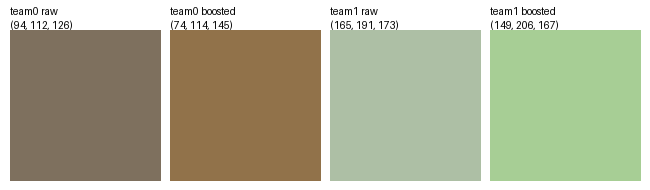

In [16]:
import colorsys
from PIL import Image, ImageDraw

def boost_saturation(bgr, factor=2.2, min_lightness=0.25, max_lightness=0.75):
    b, g, r = [c / 255.0 for c in bgr]
    h, l, s = colorsys.rgb_to_hls(r, g, b)
    s = min(1.0, s * factor)
    l = max(min_lightness, min(max_lightness, l))
    r, g, b = colorsys.hls_to_rgb(h, l, s)
    return (int(b * 255), int(g * 255), int(r * 255))

team_colors_raw = dict(team_colors)   # keep the accurate-but-muted version for reference
team_colors = {k: boost_saturation(v) for k, v in team_colors_raw.items()}

print(f"Raw extracted:  {team_colors_raw}")
print(f"Boosted (saved to cache): {team_colors}")

# ---- visualize: 4 swatches (raw team0, boosted team0, raw team1, boosted team1) ----
def bgr_to_rgb(bgr):
    b, g, r = bgr
    return (r, g, b)

SWATCH_W, SWATCH_H = 150, 150
PAD = 10
labels = ["team0 raw", "team0 boosted", "team1 raw", "team1 boosted"]
colors_bgr = [team_colors_raw[0], team_colors[0], team_colors_raw[1], team_colors[1]]

sheet = Image.new("RGB", (SWATCH_W * 4 + PAD * 5, SWATCH_H + 40), "white")
draw = ImageDraw.Draw(sheet)
for idx, (label, bgr) in enumerate(zip(labels, colors_bgr)):
    x0 = PAD + idx * (SWATCH_W + PAD)
    draw.rectangle([x0, 30, x0 + SWATCH_W, 30 + SWATCH_H], fill=bgr_to_rgb(bgr))
    draw.text((x0, 5), f"{label}\n{bgr}", fill="black")

sheet


## Cell 6 — Visual sanity check: sample crops per cluster
Now runs *after* KMeans is fit, using the torso crop that was actually embedded (previously this referenced `cluster_labels` and an undefined `get_torso_crop` before either existed, and crashed on a fresh run).

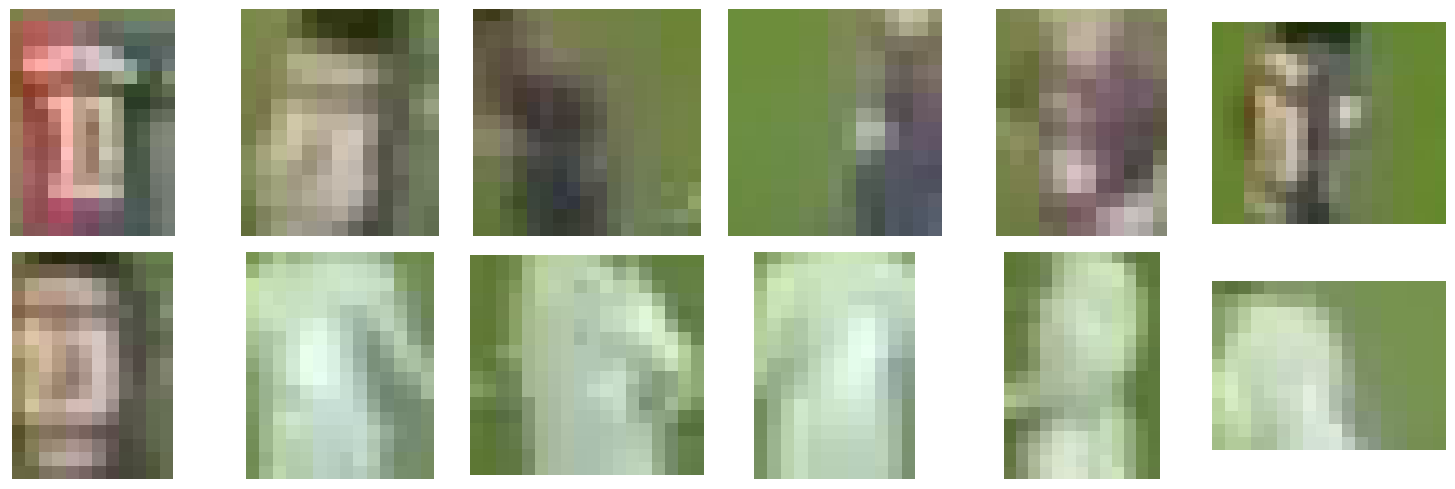

Eyeball check: each row should visually be one team's kit. If a row is mixed
(both kits present) or split by something else (motion blur, lighting), the
silhouette score above is telling the truth -- don't trust the numeric labels yet.


In [17]:
import matplotlib.pyplot as plt

cap = cv2.VideoCapture(VIDEO_PATH)
samples_per_cluster = {0: [], 1: []}

for i, (frame_idx, track_id) in enumerate(calibration_meta):
    label = cluster_labels[i]
    if len(samples_per_cluster[label]) >= 6:
        continue
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
    ret, frame = cap.read()
    if not ret:
        continue
    data = tracking_cache.get(frame_idx, {"tracks": []})
    bbox = next((t["bbox"] for t in data["tracks"] if t["track_id"] == track_id), None)
    if bbox is None:
        continue
    crop = get_torso_crop(frame, bbox)
    if crop is not None and crop.size > 0:
        samples_per_cluster[label].append(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB))

    if len(samples_per_cluster[0]) >= 6 and len(samples_per_cluster[1]) >= 6:
        break

cap.release()

fig, axes = plt.subplots(2, 6, figsize=(15, 5))
for cluster_id in [0, 1]:
    for j, crop in enumerate(samples_per_cluster[cluster_id][:6]):
        axes[cluster_id][j].imshow(crop)
        axes[cluster_id][j].axis("off")
    axes[cluster_id][0].set_ylabel(f"Cluster {cluster_id}", fontsize=12)
plt.tight_layout()
plt.show()

print("Eyeball check: each row should visually be one team's kit. If a row is mixed")
print("(both kits present) or split by something else (motion blur, lighting), the")
print("silhouette score above is telling the truth -- don't trust the numeric labels yet.")


## Cell 7 — Classify every player detection per frame
Uses the same `scaler`/`kmeans` fit in Cell 5 on the real 768-dim SigLIP features (previously this silently picked up a stale 4-dim scaler from an out-of-order run and crashed with a feature-count mismatch). Raw per-frame team assignment, not smoothed yet -- that's the next cell.

In [18]:
from tqdm.auto import tqdm

raw_team_votes = defaultdict(lambda: defaultdict(int))
per_frame_team = {}

if os.path.exists(CLASSIFICATION_CHECKPOINT_INPUT_PATH):
    print(f"Found existing checkpoint at {CLASSIFICATION_CHECKPOINT_INPUT_PATH} -- "
          f"loading instead of re-running the ~44min classification pass.")
    with open(CLASSIFICATION_CHECKPOINT_INPUT_PATH, "rb") as f:
        checkpoint = pickle.load(f)

    for tid, votes in checkpoint["raw_team_votes"].items():
        raw_team_votes[tid] = defaultdict(int, votes)
    per_frame_team = checkpoint["per_frame_team"]

    if checkpoint.get("CLASSIFICATION_FRAME_STRIDE") != CLASSIFICATION_FRAME_STRIDE:
        print(f"  [WARNING] checkpoint was built with CLASSIFICATION_FRAME_STRIDE="
              f"{checkpoint.get('CLASSIFICATION_FRAME_STRIDE')}, current config has "
              f"{CLASSIFICATION_FRAME_STRIDE} -- results may not match a fresh run "
              f"at the current setting.")
    if checkpoint.get("player_ids") is not None and checkpoint["player_ids"] != player_ids:
        print(f"  [WARNING] checkpoint's player_ids differ from the current tracking_cache's "
              f"player_ids -- likely a different tracking_cache version was used to build "
              f"this checkpoint. Treat results with caution.")

    print(f"\nLoaded {len(raw_team_votes)} player tracks, "
          f"{sum(sum(v.values()) for v in raw_team_votes.values())} total votes from checkpoint.")

else:
    print(f"No checkpoint found at {CLASSIFICATION_CHECKPOINT_INPUT_PATH} -- "
          f"running full classification pass ({total_frames} frames, "
          f"CLASSIFICATION_FRAME_STRIDE={CLASSIFICATION_FRAME_STRIDE}).")

    cap = cv2.VideoCapture(VIDEO_PATH)
    frame_idx = 0

    with tqdm(total=total_frames, desc="Classifying player teams", unit="frame") as pbar:
        while True:
            ret, frame = cap.read()
            if not ret:
                break

            if frame_idx % CLASSIFICATION_FRAME_STRIDE == 0:   # sparse sampling -- majority vote doesn't need every frame
                data = tracking_cache.get(frame_idx, {"tracks": []})
                for t in data["tracks"]:
                    if t["track_id"] not in player_ids:
                        continue
                    feat = extract_siglip_embedding(frame, t["bbox"])
                    if feat is None:
                        continue
                    scaled_feat = scaler.transform(feat.reshape(1, -1))
                    team = int(kmeans.predict(scaled_feat)[0])
                    raw_team_votes[t["track_id"]][team] += 1
                    per_frame_team[(frame_idx, t["track_id"])] = team

            frame_idx += 1
            pbar.update(1)
            pbar.set_postfix(tracks=len(raw_team_votes), votes=sum(sum(v.values()) for v in raw_team_votes.values()))

    cap.release()
    print(f"\nClassified sampled frames for {len(raw_team_votes)} player tracks.")

    # NEW: checkpoint the result to /kaggle/working/ immediately -- /kaggle/input/ is
    # read-only from within a session, so this run's own output can't overwrite the
    # input-dataset checkpoint path directly. Upload this as a new dataset version if you
    # want future sessions to pick it up from CLASSIFICATION_CHECKPOINT_INPUT_PATH too.
    with open(CLASSIFICATION_CHECKPOINT_SAVE_PATH, "wb") as f:
        pickle.dump({
            "raw_team_votes": dict(raw_team_votes),
            "per_frame_team": per_frame_team,
            "player_ids": player_ids,
            "total_frames": total_frames,
            "CLASSIFICATION_FRAME_STRIDE": CLASSIFICATION_FRAME_STRIDE,
        }, f)
    print(f"Checkpointed to {CLASSIFICATION_CHECKPOINT_SAVE_PATH} "
          f"(upload as a Kaggle dataset to skip this pass next time)")


No checkpoint found at /kaggle/input/datasets/zeinsaad/barca-atletico-first-half/team_classification_checkpoint_fixed.pkl -- running full classification pass (70327 frames, CLASSIFICATION_FRAME_STRIDE=8).


Classifying player teams:   0%|          | 0/70327 [00:00<?, ?frame/s]


Classified sampled frames for 69 player tracks.
Checkpointed to /kaggle/working/team_classification_checkpoint.pkl (upload as a Kaggle dataset to skip this pass next time)


[opus @ 0x4a213f00] Error parsing Opus packet header.


## Cell 8 — Windowed team voting: lock team per SEGMENT, not per whole track

Non-destructive — `per_frame_team` keeps the raw noisy per-frame votes
(unchanged). Instead of one majority vote over a track's entire lifespan,
votes are grouped into `TEAM_VOTE_WINDOW_FRAMES=500`-sized windows and each
window gets its own majority team. `locked_team_by_id` is kept for backward
compatibility (single stable team, only populated for tracks that never
flip). `track_team_segments` holds the full per-window history for every
track, and is the source of truth used by Cell 9 (goalkeeper centroids) and
Cell 11 (video annotation) below. Tracks whose windows disagree are printed
as `switch_suspects` — worth spot-checking against the tracking notebook's
own audit tools, since agreement between this list and that notebook's
suspicion scorer is a strong signal, and a track appearing ONLY here (not
flagged upstream) is worth reporting back as something the tracking-side
audit missed.

In [19]:
TEAM_VOTE_WINDOW_FRAMES = 500   # frames per voting window -- see intro cell for why 500
                                  # was chosen as the starting point over a smaller window

# per_frame_team is keyed by (frame_idx, track_id) -> team (from Cell 7 above).
# Restructure into track_id -> [(frame_idx, team), ...] first.
votes_by_id = defaultdict(list)
for (frame_idx, tid), team in per_frame_team.items():
    votes_by_id[tid].append((frame_idx, team))

track_team_segments = {}   # tid -> [(window_start_frame, team), ...], sorted by window_start_frame
switch_suspects = []

for tid, votes in votes_by_id.items():
    votes.sort(key=lambda x: x[0])
    windows = defaultdict(lambda: defaultdict(int))
    for f, team in votes:
        windows[f // TEAM_VOTE_WINDOW_FRAMES][team] += 1

    segments = []
    for w in sorted(windows):
        team_here = max(windows[w], key=windows[w].get)
        segments.append((w * TEAM_VOTE_WINDOW_FRAMES, team_here))
    track_team_segments[tid] = segments

    unique_teams = {t for _, t in segments}
    if len(unique_teams) > 1:
        switch_suspects.append((tid, segments))


def team_for_track_at_frame(tid, frame_idx, default=None):
    """Look up the team in effect for a track at a specific frame, using the
    windowed segments -- this is what Cell 9 and Cell 11 use instead of a
    single static label, so a mid-track flip is handled correctly wherever
    team membership actually matters."""
    segments = track_team_segments.get(tid)
    if not segments:
        return default
    team = segments[0][1]
    for window_start, team_here in segments:
        if window_start <= frame_idx:
            team = team_here
        else:
            break
    return team


print(f"{len(switch_suspects)} tracks show a team flip across windows -- likely a cross-team "
      f"ID switch surviving into the final tracking output (or a genuinely bad SigLIP "
      f"classification in some window -- check both before assuming it's a real switch):\n")
for tid, segments in switch_suspects:
    print(f"  track_id={tid}: {segments}")

# locked_team_by_id keeps its ORIGINAL meaning: single stable team, for tracks with no flip.
# Downstream code that only knows about a single per-track team (older analytics, quick
# lookups) still works unchanged for the vast majority of tracks that never flip.
locked_team_by_id = {
    tid: segments[0][1] for tid, segments in track_team_segments.items()
    if len({t for _, t in segments}) == 1
}

print(f"\n{len(locked_team_by_id)} tracks: single stable team (unchanged behavior).")
print(f"{len(switch_suspects)} tracks: need per-segment team lookup via "
      f"team_for_track_at_frame(tid, frame_idx) -- see track_team_segments.")

# Weak-majority flag (same semantics as before), now checked per-window rather than
# globally -- a window with a weak majority is noisier, not necessarily a switch.
weak_windows = []
for tid, segments in track_team_segments.items():
    votes = votes_by_id[tid]
    windows_grouped = defaultdict(lambda: defaultdict(int))
    for f, team in votes:
        windows_grouped[f // TEAM_VOTE_WINDOW_FRAMES][team] += 1
    for window_start, team_here in segments:
        w = window_start // TEAM_VOTE_WINDOW_FRAMES
        wv = windows_grouped[w]
        total = sum(wv.values())
        frac = wv[team_here] / total if total else 0
        if frac < WEAK_MAJORITY_THRESHOLD:
            weak_windows.append((tid, window_start, team_here, frac))

if weak_windows:
    print(f"\n{len(weak_windows)} individual windows below WEAK_MAJORITY_THRESHOLD="
          f"{WEAK_MAJORITY_THRESHOLD} -- check these manually:")
    for tid, window_start, team_here, frac in weak_windows[:20]:
        print(f"  id={tid} window_start={window_start} team={team_here} majority_frac={frac:.2f}")


29 tracks show a team flip across windows -- likely a cross-team ID switch surviving into the final tracking output (or a genuinely bad SigLIP classification in some window -- check both before assuming it's a real switch):

  track_id=5: [(0, 1), (500, 1), (1000, 1), (1500, 1), (2000, 1), (2500, 1), (3000, 1), (3500, 1), (4000, 1), (4500, 1), (5000, 1), (5500, 1), (6000, 1), (6500, 1), (7000, 1), (7500, 1), (8000, 1), (8500, 1), (9000, 1), (9500, 1), (10000, 1), (10500, 1), (11000, 1), (11500, 1), (12000, 1), (12500, 1), (13000, 1), (13500, 1), (14000, 1), (14500, 1), (15000, 1), (15500, 1), (16000, 1), (16500, 1), (17000, 1), (17500, 1), (18000, 1), (18500, 1), (19000, 1), (19500, 1), (20000, 1), (20500, 1), (21000, 1), (21500, 1), (22000, 1), (22500, 1), (23000, 1), (23500, 1), (24000, 1), (24500, 1), (25000, 1), (25500, 1), (26000, 1), (26500, 1), (27500, 1), (28000, 1), (28500, 1), (29000, 1), (29500, 1), (30000, 1), (30500, 1), (31000, 1), (31500, 1), (32000, 1), (32500, 1), (330

## Cell 9 — Assign goalkeepers via pitch-space centroid proximity
For each goalkeeper track, compute its average pitch-space position, and the average pitch-space position of each team's players. Assign the goalkeeper to whichever team centroid is closer. Uses pitch coordinates (via homography), not raw pixel distance -- pixel-space distance is distorted by camera perspective.

**NEW:** team centroids are now built using `team_for_track_at_frame` per sampled
position, not `locked_team_by_id` per whole track -- so a switch_suspect track's
positions are correctly split between the two teams' centroids instead of all
being attributed to whichever team won the (now-defunct) whole-track vote.

In [20]:
def project_to_pitch(point_px, H):
    pt = cv2.perspectiveTransform(
        np.array([[[point_px[0], point_px[1]]]], dtype=np.float32), H
    ).reshape(2)
    return float(pt[0] / PX_PER_METER), float(pt[1] / PX_PER_METER)


def bbox_foot_point(bbox):
    x1, y1, x2, y2 = bbox
    return ((x1 + x2) / 2, y2)


def get_track_positions_with_frame(track_id, cache=tracking_cache, sample_stride=10):
    """Pitch-space positions for a track, sampled every sample_stride frames it
    appears in -- returns (frame_idx, position) pairs so callers can look up
    which team was in effect at each sampled frame (see team_for_track_at_frame)."""
    positions = []
    for frame_idx, data in cache.items():
        if frame_idx % sample_stride != 0:
            continue
        for t in data["tracks"]:
            if t["track_id"] == track_id:
                H = get_homography(frame_idx)
                if H is not None:
                    pos = project_to_pitch(bbox_foot_point(t["bbox"]), H)
                    positions.append((frame_idx, pos))
                break
    return positions


def get_track_positions(track_id, cache=tracking_cache, sample_stride=10):
    """Backward-compatible wrapper -- positions only, no frame index."""
    return [pos for _, pos in get_track_positions_with_frame(track_id, cache, sample_stride)]


goalkeeper_ids = {tid for tid, cls in locked_class_by_id.items() if cls == "goalkeeper"}
print(f"Goalkeeper tracks to assign: {sorted(goalkeeper_ids)}")

# NEW: build team centroids from EVERY player track (not just non-flip ones in
# locked_team_by_id), attributing each sampled position to the team that was
# actually in effect at that frame via team_for_track_at_frame.
team_positions = {0: [], 1: []}
for tid in votes_by_id:   # all player tracks that got classified in Cell 7
    for frame_idx, pos in get_track_positions_with_frame(tid):
        team = team_for_track_at_frame(tid, frame_idx)
        if team is not None:
            team_positions[team].append(pos)

team_centroids = {
    team: np.mean(positions, axis=0) if positions else None
    for team, positions in team_positions.items()
}
print(f"\nTeam 0 centroid (pitch m): {team_centroids[0]}")
print(f"Team 1 centroid (pitch m): {team_centroids[1]}")

goalkeeper_team_assignment = {}
for gk_id in goalkeeper_ids:
    gk_positions = get_track_positions(gk_id)
    if not gk_positions:
        print(f"  id={gk_id}: no valid pitch positions found -- skipping")
        continue
    gk_centroid = np.mean(gk_positions, axis=0)

    dist0 = np.linalg.norm(gk_centroid - team_centroids[0]) if team_centroids[0] is not None else np.inf
    dist1 = np.linalg.norm(gk_centroid - team_centroids[1]) if team_centroids[1] is not None else np.inf

    assigned_team = 0 if dist0 < dist1 else 1
    goalkeeper_team_assignment[gk_id] = assigned_team
    print(f"  id={gk_id} | pitch pos: ({gk_centroid[0]:.1f}, {gk_centroid[1]:.1f})m "
          f"| dist_to_team0={dist0:.1f}m dist_to_team1={dist1:.1f}m -> team {assigned_team}")


Goalkeeper tracks to assign: [25, 26, 27, 28, 37, 39, 40, 43, 45, 46, 47, 52, 54, 58, 68, 72, 75, 77, 79, 88, 9002]

Team 0 centroid (pitch m): [58.96123912 34.72436057]
Team 1 centroid (pitch m): [65.43494977 34.31304776]
  id=25 | pitch pos: (15.7, 34.2)m | dist_to_team0=43.3m dist_to_team1=49.7m -> team 0
  id=26 | pitch pos: (100.4, 34.6)m | dist_to_team0=41.5m dist_to_team1=35.0m -> team 1
  id=27 | pitch pos: (9.3, 32.7)m | dist_to_team0=49.7m dist_to_team1=56.2m -> team 0
  id=28 | pitch pos: (100.2, 34.7)m | dist_to_team0=41.2m dist_to_team1=34.7m -> team 1
  id=37 | pitch pos: (17.3, 38.1)m | dist_to_team0=41.8m dist_to_team1=48.3m -> team 0
  id=39 | pitch pos: (10.9, 36.2)m | dist_to_team0=48.1m dist_to_team1=54.6m -> team 0
  id=40 | pitch pos: (101.2, 35.6)m | dist_to_team0=42.2m dist_to_team1=35.8m -> team 1
  id=9002 | pitch pos: (101.0, 33.7)m | dist_to_team0=42.0m dist_to_team1=35.5m -> team 1
  id=43 | pitch pos: (15.7, 34.7)m | dist_to_team0=43.2m dist_to_team1=49.7m

## Cell 10 — Merge and save final team assignment cache

**NEW:** the saved cache now also includes `track_team_segments` (the full
per-window history for every track) and `switch_suspects`, so downstream
consumers that care about frame-level correctness (e.g. pass-event detection,
tactical analytics) can use `team_for_track_at_frame` instead of trusting
`team_by_id` as a single static label for every track. `team_by_id` itself
still gets a best-effort single value per track for simple consumers, using
the segment with the most total votes for flip tracks (clearly a lossy
fallback -- flagged in the printout below, and NOT what should be used for
anything that needs frame accuracy).

In [22]:
final_team_by_id = dict(locked_team_by_id)
final_team_by_id.update(goalkeeper_team_assignment)

# For switch_suspect tracks (not in locked_team_by_id since they have >1 team),
# provide a best-effort single label = the segment with the most total votes,
# purely so final_team_by_id has SOME value for every track. This is a lossy
# summary -- anything needing frame accuracy must use team_for_track_at_frame /
# track_team_segments instead, not this fallback value.
for tid, segments in switch_suspects:
    votes = votes_by_id[tid]
    windows_grouped = defaultdict(lambda: defaultdict(int))
    for f, team in votes:
        windows_grouped[f // TEAM_VOTE_WINDOW_FRAMES][team] += 1
    team_totals = defaultdict(int)
    for w, wv in windows_grouped.items():
        for team, count in wv.items():
            team_totals[team] += count
    final_team_by_id[tid] = max(team_totals, key=team_totals.get)

# referees are intentionally excluded -- they have no team
referee_ids = {tid for tid, cls in locked_class_by_id.items() if cls == "referee"}
print(f"Referee tracks (no team assigned): {sorted(referee_ids)}")

with open(OUTPUT_TEAM_CACHE_PATH, "wb") as f:
    pickle.dump({
        "team_by_id": final_team_by_id,               # single-label fallback -- lossy for switch_suspects
        "track_team_segments": track_team_segments,     # frame-accurate source of truth
        "switch_suspects": [tid for tid, _ in switch_suspects],  # flag list
        "raw_team_votes": dict(raw_team_votes),
        "goalkeeper_team_assignment": goalkeeper_team_assignment,
        "team_centroids": team_centroids,
        "team_colors": team_colors,                     # NEW: auto-detected {0: (b,g,r), 1: (b,g,r)}
    }, f)

print(f"\nFinal team assignment ({len(final_team_by_id)} tracks):")
for tid in sorted(final_team_by_id):
    role = locked_class_by_id.get(tid, "?")
    flip_note = "  <-- FLIP TRACK, single label is lossy, use track_team_segments" \
        if tid in {t for t, _ in switch_suspects} else ""
    print(f"  id={tid:2d} | {role:10s} | team={final_team_by_id[tid]}{flip_note}")

print(f"\nSaved to {OUTPUT_TEAM_CACHE_PATH}")


Referee tracks (no team assigned): [1, 2, 3, 29, 31, 35, 36, 38, 41, 42, 44, 48, 53, 55, 59, 60, 65, 66, 67, 70, 71, 76, 87, 101]

Final team assignment (90 tracks):
  id= 4 | player     | team=0
  id= 5 | player     | team=1  <-- FLIP TRACK, single label is lossy, use track_team_segments
  id= 6 | player     | team=1  <-- FLIP TRACK, single label is lossy, use track_team_segments
  id= 7 | player     | team=1
  id= 8 | player     | team=1  <-- FLIP TRACK, single label is lossy, use track_team_segments
  id= 9 | player     | team=1  <-- FLIP TRACK, single label is lossy, use track_team_segments
  id=10 | player     | team=1  <-- FLIP TRACK, single label is lossy, use track_team_segments
  id=11 | player     | team=0
  id=12 | player     | team=0
  id=13 | player     | team=1  <-- FLIP TRACK, single label is lossy, use track_team_segments
  id=14 | player     | team=0  <-- FLIP TRACK, single label is lossy, use track_team_segments
  id=15 | player     | team=0
  id=16 | player     | tea

## Cell 11 — Annotate video (optional visual check)

**NEW:** player team color now comes from `team_for_track_at_frame(tid, frame_idx)`
at render time, not the static `final_team_by_id` lookup -- so a switch_suspect
track visibly changes color at the correct frame in the output video instead
of being drawn as one (possibly wrong, for part of its life) team throughout.

In [ ]:
OUTPUT_VIDEO_PATH_ = OUTPUT_VIDEO_PATH

TEAM_COLORS = {
    0: (255, 120, 0),     # blue-ish (BGR) -- team 0
    1: (0, 60, 220),      # red-ish (BGR)  -- team 1
}
GOALKEEPER_COLOR = (0, 165, 255)   # orange
REFEREE_COLOR = (40, 40, 230)      # red marker (distinct from team colors above)
BALL_COLOR = (0, 220, 255)
BALL_LOW_CONF_COLOR = (0, 140, 200)


def draw_pill_label(frame, text, x, y, color):
    font = cv2.FONT_HERSHEY_SIMPLEX
    (tw, th), _ = cv2.getTextSize(text, font, 0.5, 1)
    x1, y1 = int(x), int(y - th - 8)
    x2, y2 = int(x + tw + 12), int(y)
    cv2.rectangle(frame, (x1, y1), (x2, y2), color, -1, cv2.LINE_AA)
    cv2.putText(frame, text, (x1 + 6, y2 - 4), font, 0.5, (255, 255, 255), 1, cv2.LINE_AA)


cap = cv2.VideoCapture(VIDEO_PATH)
fps = cap.get(cv2.CAP_PROP_FPS)
w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

writer = cv2.VideoWriter(OUTPUT_VIDEO_PATH_, cv2.VideoWriter_fourcc(*"mp4v"), fps, (w, h))

frame_idx = 0
while True:
    ret, frame = cap.read()
    if not ret:
        break

    data = tracking_cache.get(frame_idx, {"ball": None, "tracks": []})

    for t in data["tracks"]:
        tid = t["track_id"]
        role = locked_class_by_id.get(tid, t["class"])
        x1, y1, x2, y2 = [int(v) for v in t["bbox"]]

        if role == "referee":
            color = REFEREE_COLOR
            label = f"#{tid} REF"
        elif role == "goalkeeper":
            color = GOALKEEPER_COLOR
            team = final_team_by_id.get(tid)
            label = f"#{tid} GK-T{team}" if team is not None else f"#{tid} GK"
        else:
            # NEW: segment-aware lookup -- correct even for switch_suspect tracks
            team = team_for_track_at_frame(tid, frame_idx, default=final_team_by_id.get(tid, -1))
            color = TEAM_COLORS.get(team, (200, 200, 200))
            label = f"#{tid} T{team}"

        if role == "goalkeeper":
            cx, cy = (x1 + x2) // 2, y2
            cv2.ellipse(frame, (cx, cy), (int((x2 - x1) * 0.5), 8), 0, 0, 360, color, 3, cv2.LINE_AA)
        else:
            cv2.rectangle(frame, (x1, y1), (x2, y2), color, 2, cv2.LINE_AA)

        draw_pill_label(frame, label, x1, y1, color)

    if data.get("ball") is not None:
        bx1, by1, bx2, by2 = [int(v) for v in data["ball"]["bbox"]]
        cx, cy = (bx1 + bx2) // 2, (by1 + by2) // 2
        r = max((bx2 - bx1) // 2, 4)
        low_conf = data["ball"].get("low_confidence", False)
        color = BALL_LOW_CONF_COLOR if low_conf else BALL_COLOR
        cv2.circle(frame, (cx, cy), r, color, 2 if not low_conf else 1, cv2.LINE_AA)

    writer.write(frame)
    if frame_idx % 200 == 0:
        print(f"rendered {frame_idx}/{total}")
    frame_idx += 1

cap.release()
writer.release()
print(f"\nDone. Saved annotated video to {OUTPUT_VIDEO_PATH_}")


In [24]:
from IPython.display import FileLink

FileLink("barca_atletico_team_assignment.pkl")

/kaggle/working/barca_atletico_team_assignment.pkl